In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Load data
train_data = pd.read_parquet("UNSW_NB15_training-set.parquet")
test_data = pd.read_parquet("UNSW_NB15_testing-set.parquet")

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (175341, 36)
Test shape: (82332, 36)


In [4]:
train_data.head(4)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,8495.365234,0,0,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,503571.312500,2,17,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,60929.230469,1,6,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,3358.622070,1,3,152.876541,90.235725,259.080170,4991.784668,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,1,1,0,0,Normal,0


In [5]:
test_data.head(5)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.09375,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,1,1,0,0,0,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.00000,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,1,1,0,0,0,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.00000,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,1,1,0,0,0,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.65625,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,2,1,0,0,0,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.00000,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,2,1,0,0,0,0,Normal,0


In [6]:
# remove attack_cat (not needed for binary classification)
train_data = train_data.drop('attack_cat', axis=1)
test_data = test_data.drop('attack_cat', axis=1)

In [7]:
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

In [8]:
print(train_data.shape)
print(test_data.shape)

train_data.info()

(175341, 35)
(82332, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit     

In [9]:
print(train_data.isnull().sum().sort_values(ascending=False).head(10))

dur        0
proto      0
service    0
state      0
spkts      0
dpkts      0
sbytes     0
dbytes     0
rate       0
sload      0
dtype: int64


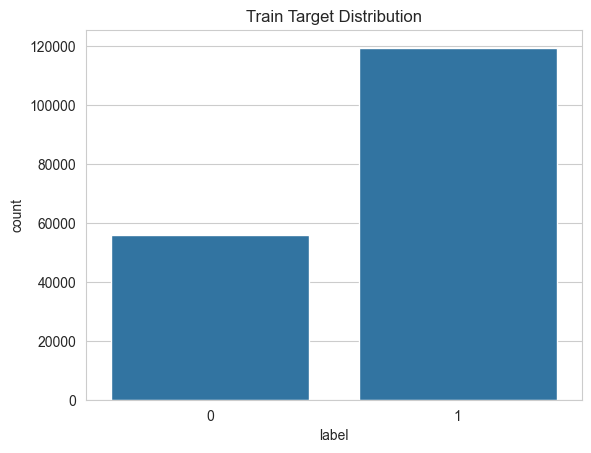

label
1    0.680622
0    0.319378
Name: proportion, dtype: float64


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=train_data)
plt.title("Train Target Distribution")
plt.show()

print(train_data['label'].value_counts(normalize=True))

In [11]:
num_cols = train_data.select_dtypes(include=np.number).columns.tolist()
cat_cols = train_data.select_dtypes(exclude=np.number).columns.tolist()

# Remove target from num_cols
num_cols.remove('label')

print("Numerical:", len(num_cols))
print("Categorical:", cat_cols)

Numerical: 31
Categorical: ['proto', 'service', 'state']


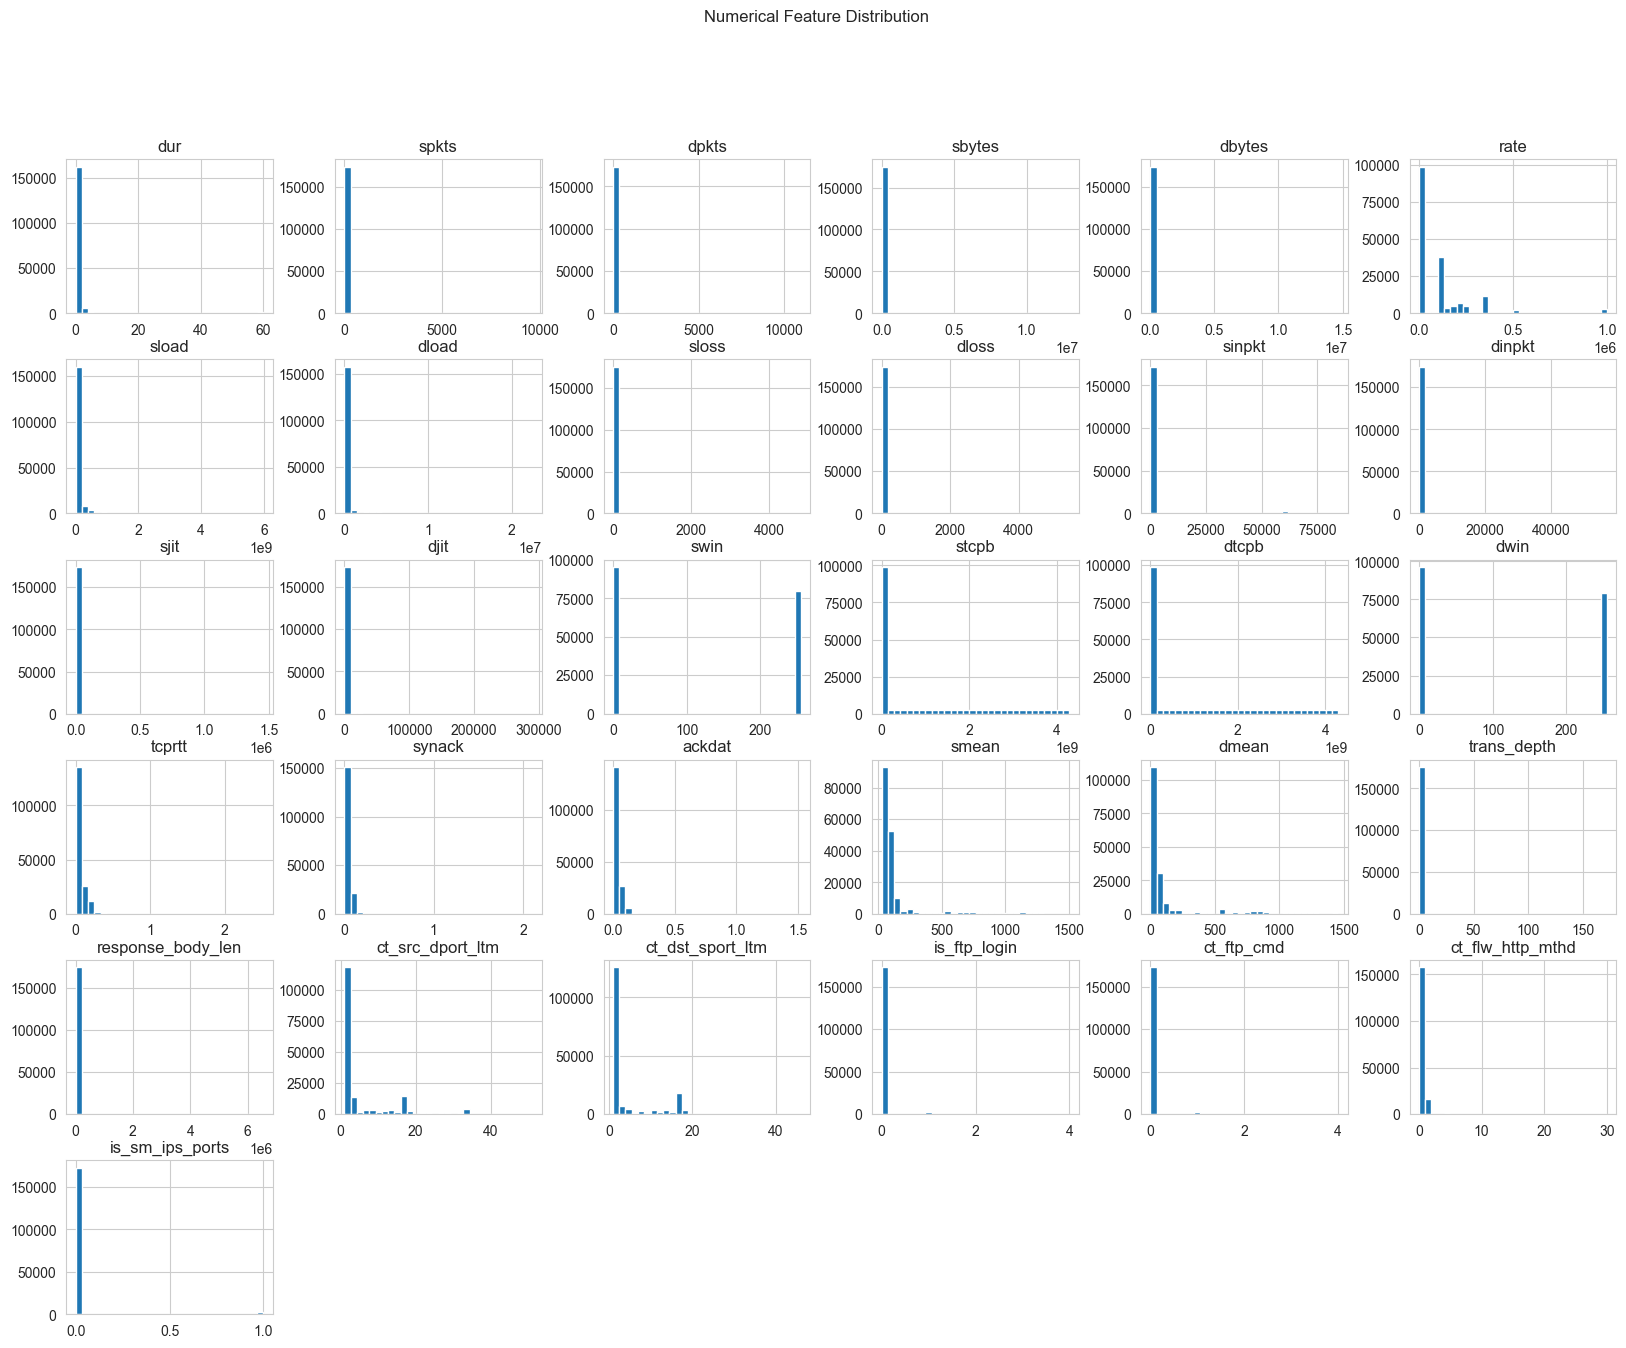

In [12]:
train_data[num_cols].hist(figsize=(20,15), bins=30)
plt.suptitle("Numerical Feature Distribution")
plt.show()

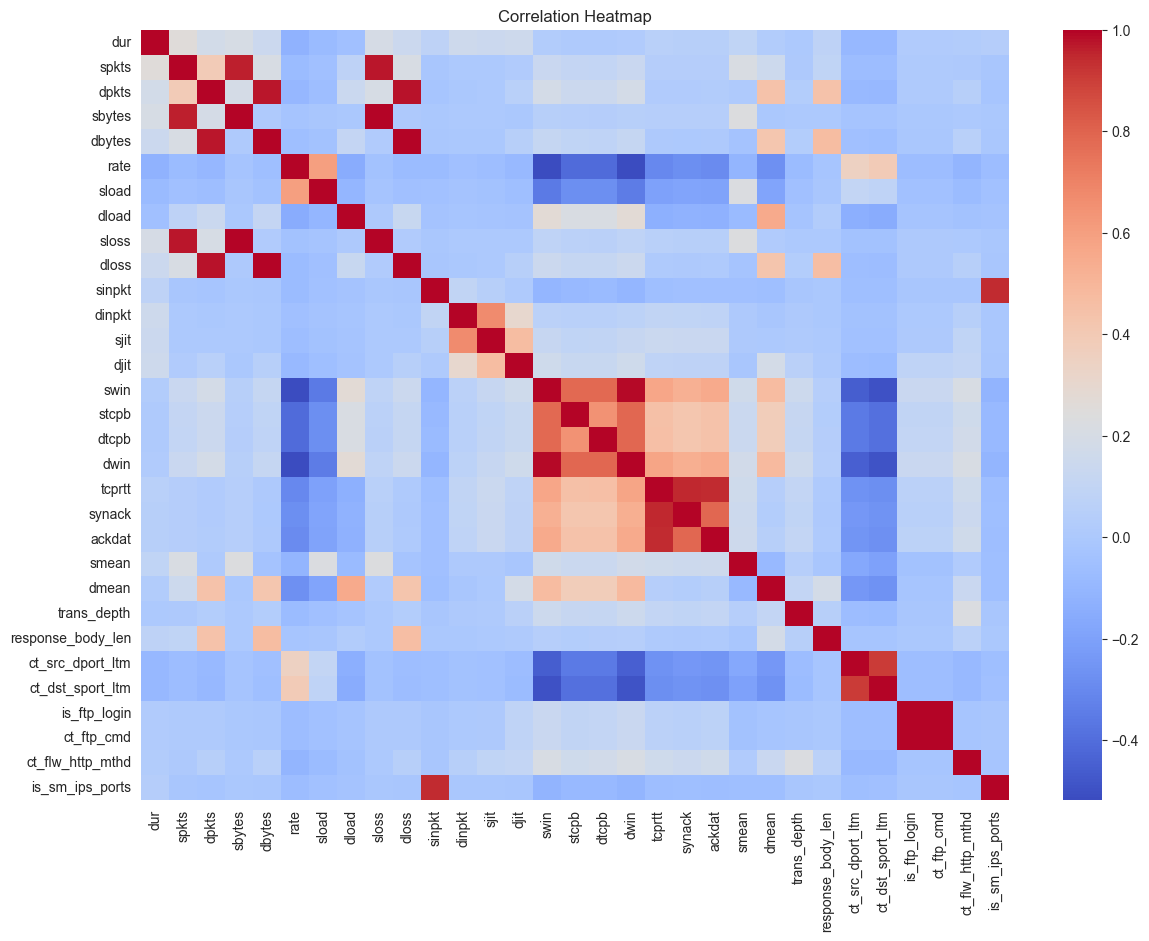

In [13]:
plt.figure(figsize=(14,10))
sns.heatmap(train_data[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

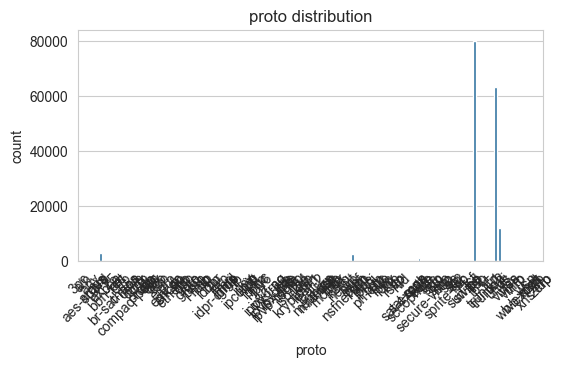

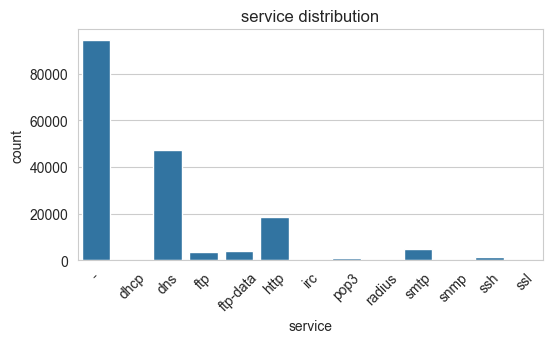

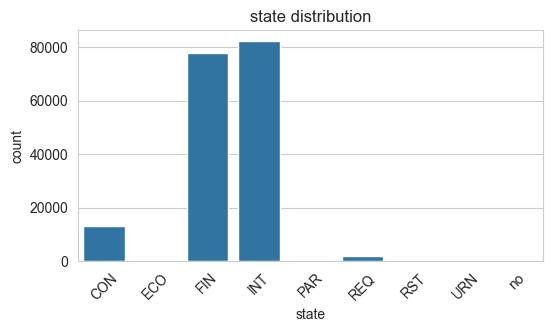

In [14]:
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=train_data)
    plt.title(f"{col} distribution")
    plt.xticks(rotation=45)
    plt.show()

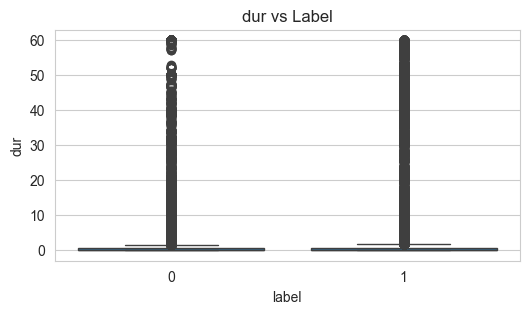

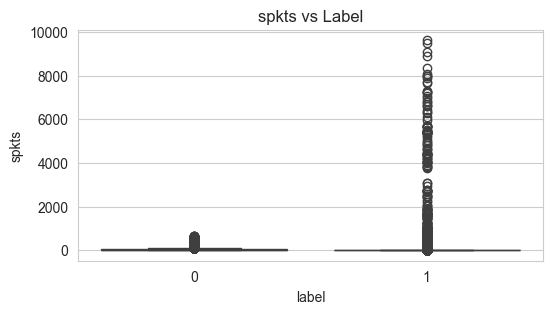

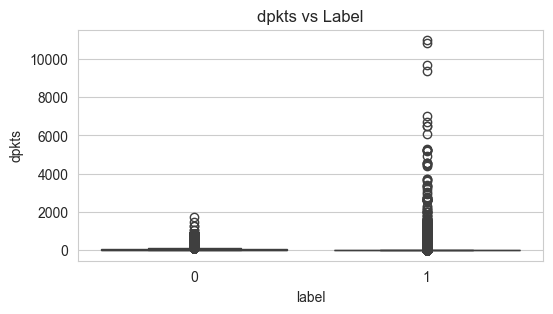

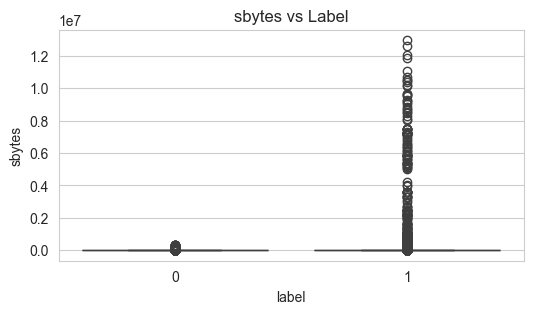

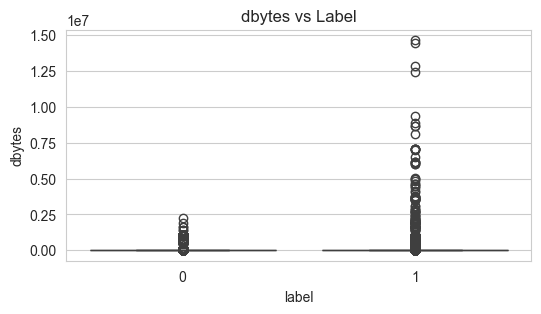

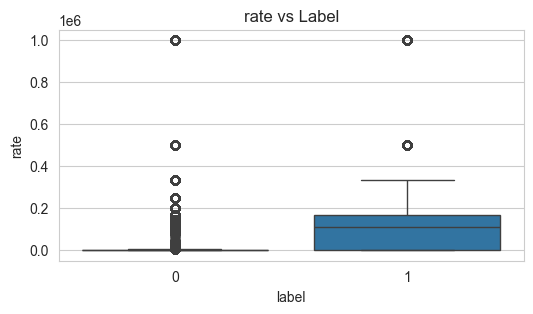

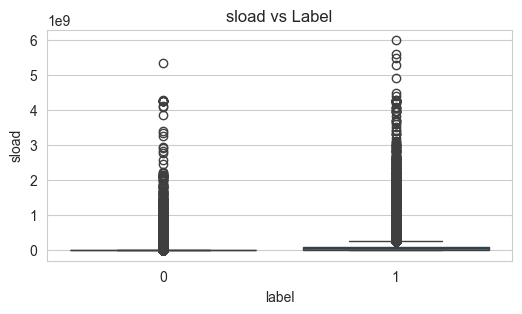

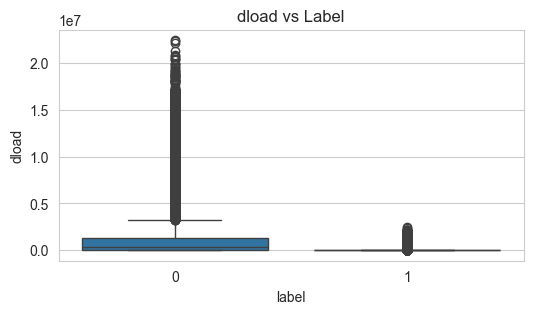

In [15]:
for col in num_cols[:8]:  # limit for readability
    plt.figure(figsize=(6,3))
    sns.boxplot(x='label', y=col, data=train_data)
    plt.title(f"{col} vs Label")
    plt.show()

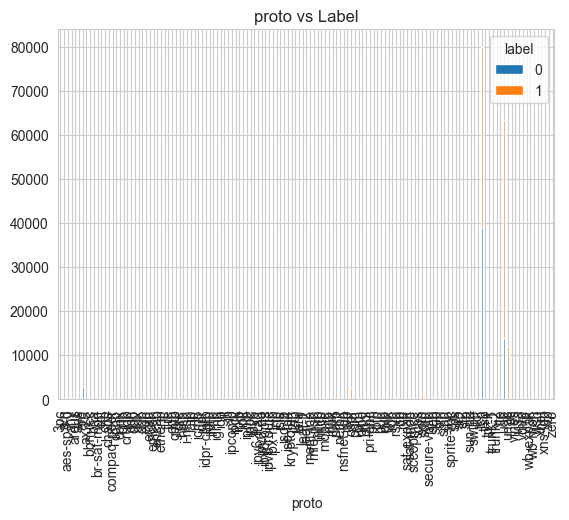

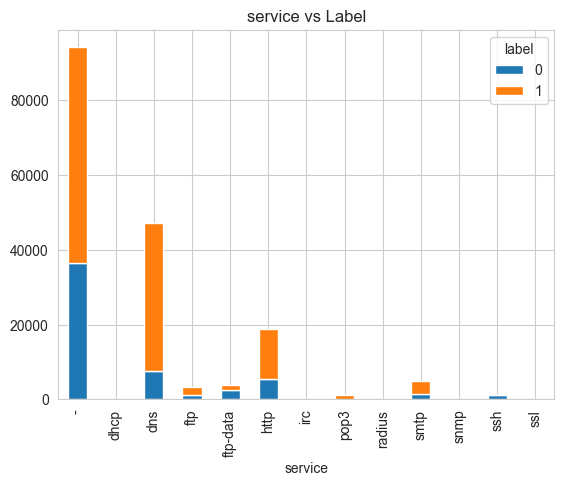

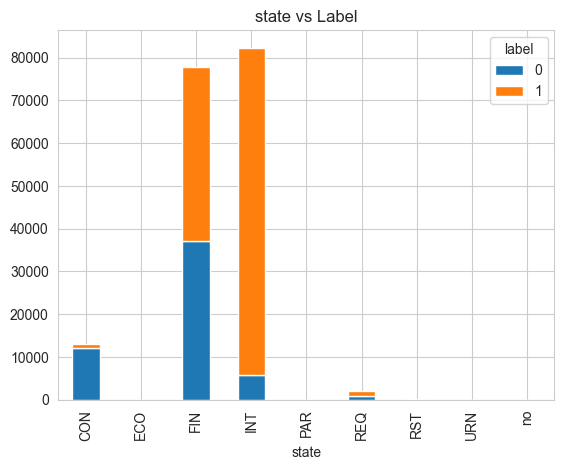

In [16]:
for col in cat_cols:
    pd.crosstab(train_data[col], train_data['label']).plot(kind='bar', stacked=True)
    plt.title(f"{col} vs Label")
    plt.show()

In [17]:
for col in num_cols:
    train_data[col].fillna(train_data[col].median(), inplace=True)
    test_data[col].fillna(train_data[col].median(), inplace=True)

for col in cat_cols:
    train_data[col].fillna(train_data[col].mode()[0], inplace=True)
    test_data[col].fillna(train_data[col].mode()[0], inplace=True)

C:\Users\malik\AppData\Local\Temp\ipykernel_18940\3838819960.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data[col].fillna(train_data[col].median(), inplace=True)
C:\Users\malik\AppData\Local\Temp\ipykernel_18940\3838819960.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [18]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_data[cat_cols] = encoder.fit_transform(train_data[cat_cols])
test_data[cat_cols] = encoder.transform(test_data[cat_cols])

In [19]:
X_train = train_data.drop('label', axis=1)
y_train = train_data['label']

X_test = test_data.drop('label', axis=1)
y_test = test_data['label']

In [20]:
print("Train duplicates:", train_data.duplicated().sum())
print("Test duplicates:", test_data.duplicated().sum())

Train duplicates: 82984
Test duplicates: 33979


In [21]:
common = pd.merge(X_train, X_test, how='inner')
print("Common rows:", common.shape)

Common rows: (3432367, 34)


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

model = DecisionTreeClassifier(
    max_depth=10,              # prevent overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9159379099256668
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     37000
           1       0.94      0.91      0.92     45332

    accuracy                           0.92     82332
   macro avg       0.91      0.92      0.92     82332
weighted avg       0.92      0.92      0.92     82332



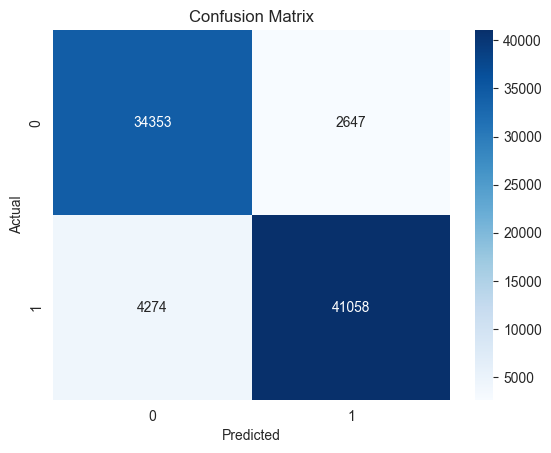

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1',   # IMPORTANT for imbalance
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV Score: 0.9488174460121632


In [29]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Accuracy: 0.9063183209444687
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     37000
           1       0.91      0.92      0.92     45332

    accuracy                           0.91     82332
   macro avg       0.91      0.90      0.91     82332
weighted avg       0.91      0.91      0.91     82332



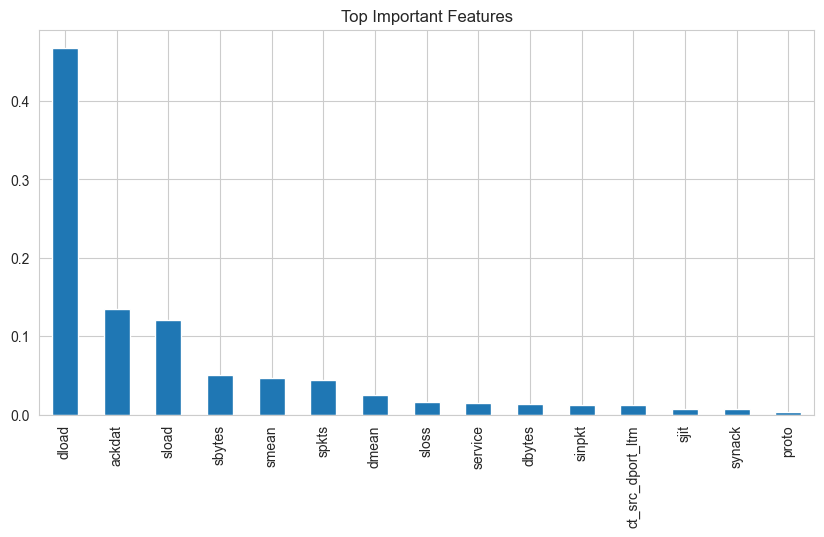

In [30]:
import pandas as pd

importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance.head(15).plot(kind='bar')
plt.title("Top Important Features")
plt.show()

In [31]:
def predict_intrusion(sample_dict, model, encoder, cat_cols, feature_order):
    import pandas as pd
    
    df = pd.DataFrame([sample_dict])
    
    # Encode categorical columns
    df[cat_cols] = encoder.transform(df[cat_cols])
    
    # Match training column order
    df = df[feature_order]
    
    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0]
    
    return pred, prob

In [32]:
feature_order = X_train.columns

In [33]:
sample_attack = {
    'dur': 0.000009,
    'proto': 'ddp',
    'service': '-',
    'state': 'INT',
    'spkts': 2,
    'dpkts': 0,
    'sbytes': 200,
    'dbytes': 0,
    'rate': 111111.109375,
    'sload': 88888888.0,
    'dload': 0.0,
    'sloss': 0,
    'dloss': 0,
    'sinpkt': 0.009,
    'dinpkt': 0.0,
    'sjit': 0.0,
    'djit': 0.0,
    'swin': 0,
    'stcpb': 0,
    'dtcpb': 0,
    'dwin': 0,
    'tcprtt': 0.0,
    'synack': 0.0,
    'ackdat': 0.0,
    'smean': 100,
    'dmean': 0,
    'trans_depth': 0,
    'response_body_len': 0,
    'ct_src_dport_ltm': 1,
    'ct_dst_sport_ltm': 1,
    'is_ftp_login': 0,
    'ct_ftp_cmd': 0,
    'ct_flw_http_mthd': 0,
    'is_sm_ips_ports': 0
}



sample_normal = {
    'dur': 0.121478,
    'proto': 'tcp',
    'service': '-',
    'state': 'FIN',
    'spkts': 6,
    'dpkts': 4,
    'sbytes': 258,
    'dbytes': 172,
    'rate': 74.087486,
    'sload': 14158.942383,
    'dload': 8495.365234,
    'sloss': 0,
    'dloss': 0,
    'sinpkt': 24.295601,
    'dinpkt': 8.375000,
    'sjit': 30.177547,
    'djit': 11.830604,
    'swin': 255,
    'stcpb': 621772692,
    'dtcpb': 2202533631,
    'dwin': 255,
    'tcprtt': 0.0,
    'synack': 0.0,
    'ackdat': 0.0,
    'smean': 43,
    'dmean': 43,
    'trans_depth': 0,
    'response_body_len': 0,
    'ct_src_dport_ltm': 1,
    'ct_dst_sport_ltm': 1,
    'is_ftp_login': 0,
    'ct_ftp_cmd': 0,
    'ct_flw_http_mthd': 0,
    'is_sm_ips_ports': 0
}

In [34]:
# Attack sample
pred, prob = predict_intrusion(
    sample_attack, best_model, encoder, cat_cols, feature_order
)

print("Attack Sample Prediction:", "Attack 🚨" if pred == 1 else "Normal ✅")
print("Probabilities:", prob)


# Normal sample
pred, prob = predict_intrusion(
    sample_normal, best_model, encoder, cat_cols, feature_order
)

print("Normal Sample Prediction:", "Attack 🚨" if pred == 1 else "Normal ✅")
print("Probabilities:", prob)

Attack Sample Prediction: Attack 🚨
Probabilities: [0. 1.]
Normal Sample Prediction: Normal ✅
Probabilities: [1. 0.]


In [35]:
import joblib

# Save model
joblib.dump(best_model, "model.pkl")

# Save encoder
joblib.dump(encoder, "encoder.pkl")

# Save feature order
joblib.dump(X_train.columns.tolist(), "features.pkl")

# Save categorical columns
joblib.dump(cat_cols, "cat_cols.pkl")

print("✅ All files saved!")

✅ All files saved!
